In [30]:
%load_ext autoreload

In [31]:
%reload_ext autoreload

In [32]:
%autoreload 2

In [33]:
import sys
import os
from pathlib import Path

In [34]:
BASE_PATH = Path(os.path.abspath('')).parent.parent.parent
sys.path.append(str(BASE_PATH))

In [1]:
import pandas as pd
import yfinance as yf
import re
import numpy as np
import datetime
from datetime import timedelta

FII_LIST = [
    'AFHI11.SA',
    'AJFI11.SA',
    'ALZC11.SA',
    'ALZM11.SA',
    'MTOF11.SA',
    'ALZR11.SA',
    'AURB11.SA',
    'APXR11.SA',
    'APXU11.SA',
    'AROA11.SA',
    'ARXD11.SA',
    'ASMT11.SA',
    'ASRF11.SA',
    'AIEC11.SA',
    'AZPE11.SA',
    'AZPL11.SA',
    'BCRI11.SA',
    'BNFS11.SA',
    'BTML11.SA',
    'BZEL11.SA',
    'BPLC11.SA',
    'BBFI11.SA',
    'BBFO11.SA',
    'BBIG11.SA',
    'BBIM11.SA',
    'BBRC11.SA',
    'RNDP11.SA',
    'BLOG11.SA',
    'BLMG11.SA',
    'BRSE11.SA',
    'BCIA11.SA',
    'CARE11.SA',
    'RTEL11.SA',
    'FATN11.SA',
    'BRCO11.SA',
    'BICE11.SA',
    'BIME11.SA',
    'BRIM11.SA',
    'BRIP11.SA',
    'BIPD11.SA',
    'BIPE11.SA',
    'BRIX11.SA',
    'BROF11.SA',
    'BETW11.SA',
    'LLAO11.SA',
    'BTHI11.SA',
    'BTLG11.SA',
    'BTYU11.SA',
    'BTWR11.SA',
    'BTSG11.SA',
    'BTSI11.SA',
    'CRFF11.SA',
    'CXRI11.SA',
    'CCME11.SA',
    'CCVA11.SA',
    'CPLG11.SA',
    'CPOF11.SA',
    'CPFF11.SA',
    'CPTS11.SA',
    'CPSH11.SA',
    'CACR11.SA',
    'CBOP11.SA',
    'BLCA11.SA',
    'CENU11.SA',
    'CFHI11.SA',
    'CFII11.SA',
    'CJCT11.SA',
    'CIXM11.SA',
    'CIXR11.SA',
    'CLIN11.SA',
    'CSMC11.SA',
    'RENV11.SA',
    'CVPR11.SA',
    'CYCR11.SA',
    'CYLD11.SA',
    'DAMA11.SA',
    'DLMT11.SA',
    'DPRO11.SA',
    'DEVA11.SA',
    'DAMT11.SA',
    'DOVL11.SA',
    'EDGE11.SA',
    'EMET11.SA',
    'EGYR11.SA',
    'EQIR11.SA',
    'ERCR11.SA',
    'ERPA11.SA',
    'KEVE11.SA',
    'EXES11.SA',
    'FLCR11.SA',
    'FAGL11.SA',
    'FARU11.SA',
    'VRTA11.SA',
    'VRTM11.SA',
    'BMII11.SA',
    'FIIC11.SA',
    'LRDI11.SA',
    'MMPD11.SA',
    'IBCR11.SA',
    'IDGR11.SA',
    'IDUA11.SA',
    'GAME11.SA',
    'TRBL11.SA',
    'ANCR11.SA',
    'FAED11.SA',
    'BMLC11.SA',
    'BPRP11.SA',
    'BRCR11.SA',
    'FCFL11.SA',
    'CNES11.SA',
    'CEOC11.SA',
    'FAMB11.SA',
    'EDGA11.SA',
    'ELDO11.SA',
    'HCRI11.SA',
    'NSLU11.SA',
    'HTMX11.SA',
    'MAXR11.SA',
    'NVHO11.SA',
    'PQDP11.SA',
    'PATB11.SA',
    'RBRM11.SA',
    'RBRR11.SA',
    'RECR11.SA',
    'RECT11.SA',
    'SHDP11.SA',
    'SAIC11.SA',
    'ALMI11.SA',
    'TRNT11.SA',
    'WTSP11.SA',
    'LVBI11.SA',
    'BRHT11.SA',
    'BPFF11.SA',
    'BVAR11.SA',
    'BPML11.SA',
    'BTRA11.SA',
    'CXCI11.SA',
    'CXCE11.SA',
    'CXTL11.SA',
    'CTXT11.SA',
    'CJFI11.SA',
    'FLMA11.SA',
    'EGDB11.SA',
    'EDFO11.SA',
    'EURO11.SA',
    'EZTB11.SA',
    'ABCP11.SA',
    'GTWR11.SA',
    'HERM11.SA',
    'HUCG11.SA',
    'HUSC11.SA',
    'FIIB11.SA',
    'FINF11.SA',
    'JKDF11.SA',
    'JKEF11.SA',
    'FMOF11.SA',
    'MVFI11.SA',
    'OULG11.SA',
    'PABY11.SA',
    'FPNG11.SA',
    'ESTQ11.SA',
    'VPSI11.SA',
    'FPAB11.SA',
    'QNTS11.SA',
    'RBRY11.SA',
    'RBRP11.SA',
    'ANGC11.SA',
    'RCRB11.SA',
    'RBED11.SA',
    'RBVA11.SA',
    'RNGO11.SA',
    'FISC11.SA',
    'SCPF11.SA',
    'SFFI11.SA',
    'SHPH11.SA',
    'SMRE11.SA',
    'TGAR11.SA',
    'TGRU11.SA',
    'TMFI11.SA',
    'BARI11.SA',
    'VERE11.SA',
    'FVPQ11.SA',
    'FIVN11.SA',
    'FBTS11.SA',
    'VTLT11.SA',
    'VSHO11.SA',
    'IDFI11.SA',
    'FAVM11.SA',
    'FIGV11.SA',
    'PLCR11.SA',
    'VTPL11.SA',
    'RELG11.SA',
    'CVBI11.SA',
    'MCCI11.SA',
    'ATWN11.SA',
    'BTAL11.SA',
    'CXCO11.SA',
    'HOSI11.SA',
    'MGHT11.SA',
    'RECX11.SA',
    'PVBI11.SA',
    'DVFF11.SA',
    'RFOF11.SA',
    'VTPA11.SA',
    'VTXI11.SA',
    'VVMR11.SA',
    'FTRE11.SA',
    'BCFF11.SA',
    'NCHB11.SA',
    'BTCI11.SA',
    'HRES11.SA',
    'N4V111.SA',
    'IRDM11.SA',
    'VCHG11.SA',
    'FLNR11.SA',
    'JCIN11.SA',
    'HLMB11.SA',
    'SBCL11.SA',
    'FRHY11.SA',
    'GARE11.SA',
    'SPVJ11.SA',
    'KFOF11.SA',
    'PULV11.SA',
    'HOMS11.SA',
    'SNEL11.SA',
    'BLUR11.SA',
    'LKDV11.SA',
    'RBRI11.SA',
    'SPXS11.SA',
    'APXM11.SA',
    'BRLA11.SA',
    'CXAG11.SA',
    'HBCR11.SA',
    'MINT11.SA',
    'OPTM11.SA',
    'RZTR11.SA',
    'ROOF11.SA',
    'TCIN11.SA',
    'GCDL11.SA',
    'GCRI11.SA',
    'GCOI11.SA',
    'GZIT11.SA',
    'GSFI11.SA',
    'FIGS11.SA',
    'VXXV11.SA',
    'GLOG11.SA',
    'MALL11.SA',
    'GGRC11.SA',
    'GRRO11.SA',
    'RCFA11.SA',
    'HABT11.SA',
    'ATCR11.SA',
    'EVBI11.SA',
    'HCTR11.SA',
    'HCST11.SA',
    'HCHG11.SA',
    'HAAA11.SA',
    'ATSA11.SA',
    'HGBL11.SA',
    'HGBS11.SA',
    'HDEL11.SA',
    'FLRP11.SA',
    'HLOG11.SA',
    'HOFC11.SA',
    'HDOF11.SA',
    'HRDF11.SA',
    'HREC11.SA',
    'SEED11.SA',
    'HPDP11.SA',
    'HFOF11.SA',
    'YEES11.SA',
    'HGIC11.SA',
    'HILG11.SA',
    'HSAF11.SA',
    'HSLG11.SA',
    'HSML11.SA',
    'HSRE11.SA',
    'HUSI11.SA',
    'IVCI11.SA',
    'GRUL11.SA',
    'ICNE11.SA',
    'RNOV11.SA',
    'FMOB11.SA',
    'IMMV11.SA',
    'INDE11.SA',
    'ITIP11.SA',
    'ITIT11.SA',
    'BICR11.SA',
    'IBBP11.SA',
    'ISCJ11.SA',
    'IRBL11.SA',
    'IRIM11.SA',
    'ICRI11.SA',
    'TMPS11.SA',
    'ITRI11.SA',
    'JCDB11.SA',
    'JCDA11.SA',
    'JASC11.SA',
    'JBFO11.SA',
    'VJFD11.SA',
    'JFLL11.SA',
    'RDLS11.SA',
    'JCCJ11.SA',
    'JPPC11.SA',
    'JPPA11.SA',
    'JSAF11.SA',
    'JSRE11.SA',
    'JSCR11.SA',
    'JTPR11.SA',
    'KISU11.SA',
    'KIVO11.SA',
    'KRES11.SA',
    '003H11.SA',
    'KCRE11.SA',
    'KLOG11.SA',
    'KFEN11.SA',
    'KNHF11.SA',
    'KNHY11.SA',
    'KNRE11.SA',
    'KNIP11.SA',
    'KOPI11.SA',
    'KORE11.SA',
    'KNPR11.SA',
    'KNRI11.SA',
    'KNCR11.SA',
    'KNSC11.SA',
    'KNUQ11.SA',
    'LPLP11.SA',
    'SLDZ11.SA',
    'LRED11.SA',
    'LSOI11.SA',
    'LASC11.SA',
    'LSPA11.SA',
    'LIFE11.SA',
    'LOFT11.SA',
    'LFTT11.SA',
    'LGCP11.SA',
    'LUGG11.SA',
    'MANA11.SA',
    'MMVE11.SA',
    'MCHY11.SA',
    'MXRF11.SA',
    'MBBI11.SA',
    'MCEM11.SA',
    'MFII11.SA',
    'MFAI11.SA',
    'MFCR11.SA',
    'MGRI11.SA',
    'SHOP11.SA',
    'DRIT11.SA',
    'MOFF11.SA',
    'NCRI11.SA',
    'NAVT11.SA',
    'APTO11.SA',
    'NEWL11.SA',
    'NEWU11.SA',
    'NVIF11.SA',
    'OCRE11.SA',
    'ONDV11.SA',
    'ARRI11.SA',
    'OBAL11.SA',
    'FTCE11.SA',
    'OUJP11.SA',
    'PNCR11.SA',
    'PNDL11.SA',
    'PNLM11.SA',
    'PNPR11.SA',
    'PNRC11.SA',
    'PMIS11.SA',
    'VTVI11.SA',
    'PQAG11.SA',
    'PATA11.SA',
    'PATC11.SA',
    'HGRE11.SA',
    'HGFF11.SA',
    'HGLG11.SA',
    'PATL11.SA',
    'HGPO11.SA',
    'HGCR11.SA',
    'HGRU11.SA',
    'PEMA11.SA',
    'PRSN11.SA',
    'PORD11.SA',
    'PLRI11.SA',
    'PCAS11.SA',
    'PRZS11.SA',
    'PRSV11.SA',
    'PBLV11.SA',
    'IMOF11.SA',
    'QTZD11.SA',
    'RZZI11.SA',
    'RSPD11.SA',
    'RBDS11.SA',
    'RBIR11.SA',
    'RBLG11.SA',
    'RRCI11.SA',
    'FIIP11.SA',
    'RBRD11.SA',
    'RBTS11.SA',
    'RBRF11.SA',
    'RCFF11.SA',
    'RDCI11.SA',
    'RDLI11.SA',
    'RBRL11.SA',
    'RBRX11.SA',
    'RPRI11.SA',
    'TOPP11.SA',
    'RMAI11.SA',
    'RINV11.SA',
    'RECD11.SA',
    'RBHG11.SA',
    'RBHY11.SA',
    'RBVO11.SA',
    'RBFF11.SA',
    'RBOP11.SA',
    'RBRS11.SA',
    'RZAK11.SA',
    'RZAT11.SA',
    'RZLC11.SA',
    'RCKF11.SA',
    'SADI11.SA',
    'SAPI11.SA',
    'SARE11.SA',
    'FISD11.SA',
    'SEQR11.SA',
    'WPLZ11.SA',
    'REIT11.SA',
    'SJAU11.SA',
    'SOLR11.SA',
    'SPTW11.SA',
    'SPAF11.SA',
    'LTMT11.SA',
    'DVLP11.SA',
    'DVLT11.SA',
    'PMFO11.SA',
    'SPGM11.SA',
    'SPXG11.SA',
    'SPXL11.SA',
    'STRX11.SA',
    'SNFF11.SA',
    'SNLG11.SA',
    'SNME11.SA',
    'SNCI11.SA',
    'SPMO11.SA',
    'TELD11.SA',
    'TELM11.SA',
    'TEPP11.SA',
    'TSER11.SA',
    'TVRI11.SA',
    'VOTS11.SA',
    'TJKB11.SA',
    'TORD11.SA',
    'TSNC11.SA',
    'TCPF11.SA',
    'TRXF11.SA',
    'TRXB11.SA',
    'URHF11.SA',
    'URPR11.SA',
    'VVCO11.SA',
    'VVCR11.SA',
    'VVRI11.SA',
    'VGIR11.SA',
    'VGIP11.SA',
    'VGII11.SA',
    'VGHF11.SA',
    'VGRI11.SA',
    'QAGR11.SA',
    'BLMO11.SA',
    'RVBI11.SA',
    'VCJR11.SA',
    'VCRR11.SA',
    'VLJS11.SA',
    'SALI11.SA',
    'VCTH11.SA',
    'VSLH11.SA',
    'VIDS11.SA',
    'VDSV11.SA',
    'VCRI11.SA',
    'VIUR11.SA',
    'VIFI11.SA',
    'VILG11.SA',
    'VINO11.SA',
    'VISC11.SA',
    'WSEC11.SA',
    'SPDE11.SA',
    'WHGR11.SA',
    'XPCM11.SA',
    'XPCI11.SA',
    'XPIN11.SA',
    'XPLG11.SA',
    'XPML11.SA',
    'XPPR11.SA',
    'XPSF11.SA',
    'XPCE11.SA',
    'YUFI11.SA',
    'ZAGH11.SA',
    'ZAVC11.SA',
    'ZAVI11.SA',
    'ZIFI11.SA'
]

In [3]:
start_date = '2020-01-01'

yf_obj = yf.Tickers(re.sub(r"'|,|\[|\]", "", str(FII_LIST)))
today = datetime.date.today()

df_portfolio = pd.DataFrame()
for ticker in yf_obj.tickers.keys():
    if ticker not in df_portfolio.columns:
        print(ticker)
        df_ticker = yf_obj.tickers[ticker].history(start=start_date, end=today)
        if len(df_ticker) > 0:
            df_ticker["ticker"] = ticker
            # df_ticker["log_return"] = np.log(df_ticker["Close"] / df_ticker["Close"].shift(1))
            # df_ticker["log_return"] = df_ticker["log_return"].fillna(0)
            df_ticker = df_ticker.reset_index()
            df_ticker = df_ticker.rename(columns={
                "Date": "date",
                "Open": "open",
                "High": "high",
                "Low": "low",
                "Close": "close",
                "Volume": "volume"
            })
            df_ticker["event_time"] = datetime.datetime.now()
            df_ticker["date"] = pd.to_datetime(df_ticker["date"]).dt.date
            df_ticker = df_ticker[["date", "ticker", "open", "high", "low", "close", "volume", "event_time"]]
            df_portfolio = pd.concat([df_portfolio, df_ticker])

AFHI11.SA
AJFI11.SA
ALZC11.SA
ALZM11.SA
MTOF11.SA


$MTOF11.SA: possibly delisted; no timezone found


ALZR11.SA
AURB11.SA
APXR11.SA
APXU11.SA
AROA11.SA
ARXD11.SA
ASMT11.SA


HTTP Error 404: 
$ASMT11.SA: possibly delisted; no timezone found


ASRF11.SA
AIEC11.SA
AZPE11.SA


...

VCRI11.SA
VIUR11.SA
VIFI11.SA
VILG11.SA
VINO11.SA
VISC11.SA
WSEC11.SA
SPDE11.SA
WHGR11.SA
XPCM11.SA
XPCI11.SA
XPIN11.SA
XPLG11.SA
XPML11.SA
XPPR11.SA


$XPPR11.SA: possibly delisted; no timezone found


XPSF11.SA
XPCE11.SA


$XPCE11.SA: possibly delisted; no timezone found


YUFI11.SA
ZAGH11.SA
ZAVC11.SA
ZAVI11.SA
ZIFI11.SA


In [20]:
portfolio = df_portfolio.pivot_table(values="close", index="date", columns="ticker")
portfolio.columns = [n.replace(".SA", "") for n in portfolio.columns]
portfolio = np.log(portfolio / portfolio.shift(1))
portfolio = portfolio.fillna(0.)
portfolio = portfolio.reset_index()
portfolio.to_csv("fiis_portfolio_returns.csv", index=False)
portfolio

/Users/gustavo/Desktop/Doutorado - EEC-I/Pesquisa/bandits-lib/venv/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


,date,ABCP11,AFHI11,AIEC11,AJFI11,ALMI11,ALZC11,ALZM11,ALZR11,ANCR11,...,XPIN11,XPLG11,XPML11,XPSF11,YEES11,YUFI11,ZAGH11,ZAVC11,ZAVI11,ZIFI11
0,2020-01-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1,2020-01-03,0.002302,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.029563,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
2,2020-01-06,-0.002118,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.016172,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3,2020-01-07,0.009174,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.011043,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
4,2020-01-08,-0.020016,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.046517,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,2025-08-27,0.000119,-0.000541,-0.007523,0.002653,0.000000,-0.004030,0.0,0.001998,0.000000,...,0.003209,0.001826,0.005028,-0.001671,0.0,0.0,0.033271,-0.021852,-0.010528,0.067967
1408,2025-08-28,-0.003922,0.002163,0.006023,0.000000,0.000000,0.001345,0.0,0.000997,0.000000,...,0.014888,-0.005283,0.004404,0.000000,0.0,0.0,-0.100134,0.011561,0.010183,-0.001970
1409,2025-08-29,0.004278,0.001080,0.007903,0.006601,0.000000,0.001343,0.0,0.010907,0.000000,...,0.004152,0.011547,0.017423,0.014938,0.0,0.0,0.083637,0.008014,-0.003922,0.000000
1410,2025-09-01,-0.000358,-0.005737,0.000000,-0.003955,0.006847,0.010681,0.0,0.000000,0.000000,...,-0.005588,0.000203,0.016063,-0.022738,0.0,0.0,0.000000,0.024015,0.006535,0.000000


In [23]:
portfolio = pd.read_csv("fiis_portfolio_returns.csv")
portfolio = portfolio.set_index('date')
portfolio

,ABCP11,AFHI11,AIEC11,AJFI11,ALMI11,ALZC11,ALZM11,ALZR11,ANCR11,APTO11,...,XPIN11,XPLG11,XPML11,XPSF11,YEES11,YUFI11,ZAGH11,ZAVC11,ZAVI11,ZIFI11
date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
2020-01-03,0.002302,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.029563,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
2020-01-06,-0.002118,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.016172,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
2020-01-07,0.009174,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.011043,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
2020-01-08,-0.020016,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.046517,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-27,0.000119,-0.000541,-0.007523,0.002653,0.000000,-0.004030,0.0,0.001998,0.000000,0.002367,...,0.003209,0.001826,0.005028,-0.001671,0.0,0.0,0.033271,-0.021852,-0.010528,0.067967
2025-08-28,-0.003922,0.002163,0.006023,0.000000,0.000000,0.001345,0.0,0.000997,0.000000,0.000000,...,0.014888,-0.005283,0.004404,0.000000,0.0,0.0,-0.100134,0.011561,0.010183,-0.001970
2025-08-29,0.004278,0.001080,0.007903,0.006601,0.000000,0.001343,0.0,0.010907,0.000000,0.002361,...,0.004152,0.011547,0.017423,0.014938,0.0,0.0,0.083637,0.008014,-0.003922,0.000000


In [26]:
import matplotlib.pyplot as plt

In [45]:
portfolio.sum().sort_values(ascending=False)

FLRP11    41.974783
TSNC11     9.020632
BVAR11     8.742359
RNDP11     5.611046
CPTS11     4.302472
            ...    
TORD11    -2.851375
CXRI11    -2.906945
FISC11    -2.918762
EGYR11    -3.389678
RBDS11    -3.533369
Length: 388, dtype: float64

Text(0, 0.5, 'Cumulative Returns')

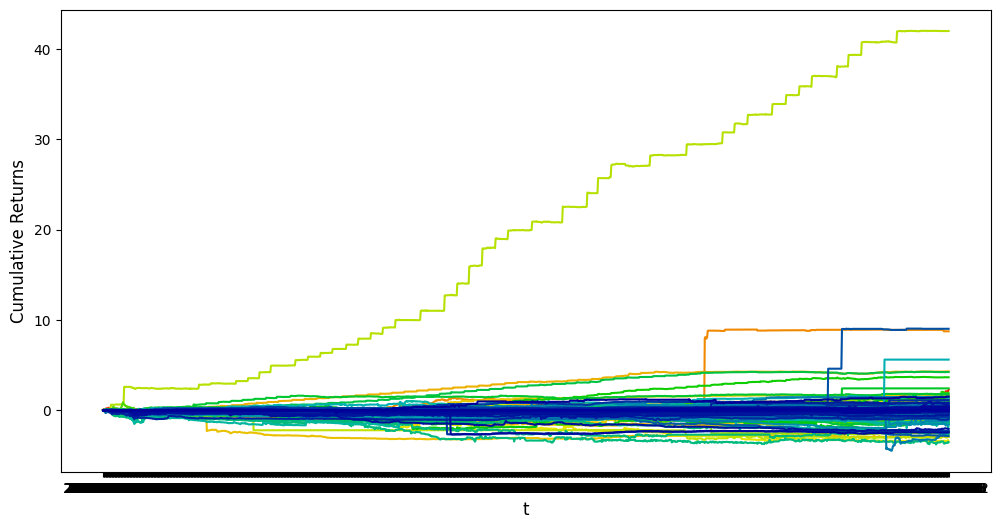

In [27]:
from colour import Color

blue = Color("red", luminance=0.5)
colors = list(blue.range_to(Color("blue", luminance=0.3), len(portfolio.columns)))

# with plt.style.context(['science', 'ieee', 'no-latex']):
fig, ax = plt.subplots(figsize=(12, 6))
i = 0
for col in portfolio.columns:
    plt.plot(portfolio[col].cumsum(), color=colors[i].rgb, linestyle="-")
    i += 1
#     plt.legend(portfolio.columns, fontsize=4)
plt.xlabel('t', fontsize=12)
plt.ylabel('Cumulative Returns', fontsize=12)
# plt.savefig('01_classes.jpg', dpi=600)

In [28]:
portfolio_size = 10

bandit_net_policies = {
    f"Two Stage ADTS (mean) | (n={portfolio_size})": {
        "network_name": "BanditNetwork",
        "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
        "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.2, "f": "mean", "w": 200},
        "policy_name": "AdaptiveDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.2, "f": "mean", "w": 200},
        "combinatorial_agents": [],
        "agents": [],
        "chosen_superarms": []
    }
}

In [35]:
from bandits_lib.replay_engines.interface import BanditNetworkBacktestInterface

bandit_backtester = BanditNetworkBacktestInterface(
    bandit_policies=bandit_net_policies,
    portfolio_size=portfolio_size,
    n_simulations=10,
    reward_function="WindowedReturnArm",
    reward_function_args=dict(window=120),
    portfolio=portfolio,
)
bandit_backtester.run()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:42<00:00,  4.23s/it]


In [36]:
blue = Color("orange", luminance=0.5)
colors = list(blue.range_to(Color("blue", luminance=0.3), len(bandit_backtester.bandit_policies)))

In [42]:
from bandits_lib.replay_engines.interface import interpolate_colors

def plot_rewards(obj,                 
                 save_fig: bool = False,
                 figure_name: str = None,
                 oracle: np.ndarray = None,
                 oracle_name: str = "Oracle",
                 personalized_colors: list = None,
                 color_start: str = "#1f77b4",
                 color_end: str = "#ff7f0e"):

    if save_fig and figure_name is None:
        raise ValueError("Please provide a figure name to save the plot.")
    
    # Default Matplotlib blue and orange
    color_vector_size = len(obj.bandit_policies)
    colors = interpolate_colors(color_start, color_end, color_vector_size)
    if personalized_colors is not None:
        colors = personalized_colors
    
    plt.subplots(figsize=(12, 6))

    if oracle is not None:
        plt.plot(obj.portfolio.index, np.exp(np.cumsum(oracle)), color='black', linestyle='-', label=oracle_name)

    i = 0
    for policy, output in obj.bandit_policies.items():
        plt.plot(obj.portfolio.index, np.exp(np.cumsum(output['mean_reward'])), color=colors[i], linestyle='-', label=policy)
        i += 1
    plt.legend(loc='upper left', fontsize=7)
    plt.xlabel('t', fontsize=10)
    plt.ylabel('Cumulative Returns', fontsize=10)

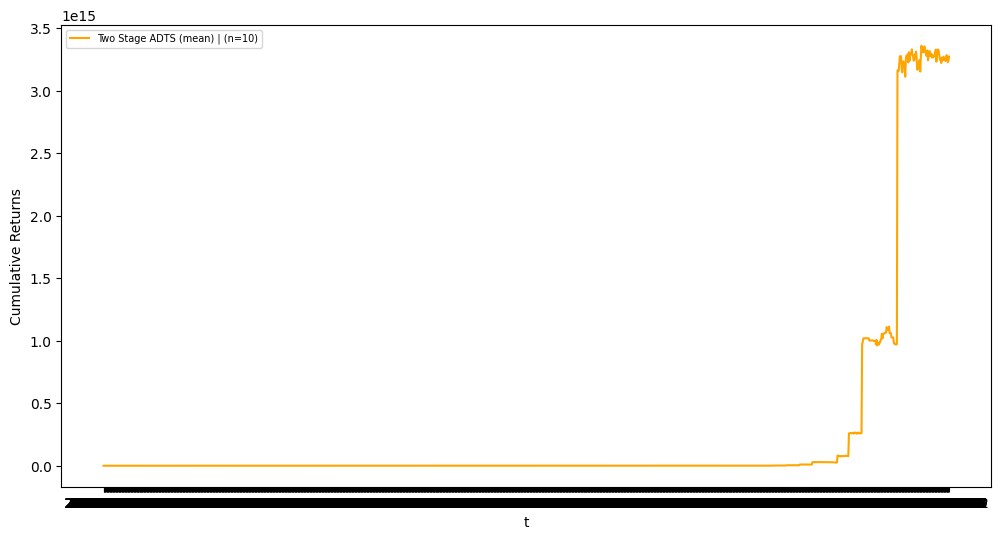

In [43]:
plot_rewards(
    bandit_backtester,
    # save_fig=True,
    # figure_name="03_rewards_versus_oracle_portfolio.jpg",
    # oracle=df_merge['CMC 200'].values,
    # oracle_name='CMC 200 Index',
    personalized_colors=[c.rgb for c in colors]
)
# ax = plt.gca()
# ax.legend(['a'])
# plt.plot(data[['^CMC200']].cumsum())
# plt.show()

In [47]:
bandit_arms = bandit_backtester.bandit_policies[f"Two Stage ADTS (mean) | (n={portfolio_size})"]['chosen_superarms'][1]['bandit_arms']
weights = bandit_backtester.bandit_policies[f"Two Stage ADTS (mean) | (n={portfolio_size})"]['chosen_superarms'][1]['weights']
print(bandit_arms[-1], weights[-1])

[8, 50, 85, 115, 176, 227, 244, 292, 313, 350] [0.00212465 0.00424929 0.00566572 0.96104816 0.00495751 0.00354108
 0.00212465 0.00849858 0.00424929 0.00354108]


In [48]:
columns = list(portfolio.columns)
{columns[i]: weights[-1][i] for i in range(len(bandit_arms[-1]))}

{'ABCP11': np.float64(0.002124645892351275),
 'AFHI11': np.float64(0.00424929178470255),
 'AIEC11': np.float64(0.0056657223796034),
 'AJFI11': np.float64(0.9610481586402266),
 'ALMI11': np.float64(0.004957507082152974),
 'ALZC11': np.float64(0.0035410764872521247),
 'ALZM11': np.float64(0.002124645892351275),
 'ALZR11': np.float64(0.0084985835694051),
 'ANCR11': np.float64(0.00424929178470255),
 'APTO11': np.float64(0.0035410764872521247)}